In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import pyscisci.all as pyscisci
from brokenaxes import brokenaxes
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import LogLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker
from scipy.stats import norm, ks_2samp
import matplotlib.lines as mlines
from scipy.stats import ks_2samp, sem
import dask.dataframe as dd
from adjustText import adjust_text
from itertools import combinations
from tqdm import tqdm
import pickle
import unicodedata
import html
import regex
import re
from rapidfuzz import process as rf_process
from rapidfuzz import fuzz
import spacy
from scipy.stats import ttest_ind
tqdm.pandas()  # 注册 tqdm 的 DataFrame 扩展

# 定义字体
EF = FontProperties(family = 'DejaVu Sans')
main_path = r'/home/20250114zmz_kd/'
%matplotlib inline

In [2]:
data = r'Co-utilization/1-Revision202501-DataProcess/9-PanelData_20250303-adddicesimilarity.csv'
ddf = pd.read_csv(main_path + data)
del ddf['Unnamed: 0']
print(ddf .shape)
ddf .columns

(25410, 23)


Index(['work_id', 'facility_pair', 'times_cited_3', 'times_cited_5',
       'times_cited_10', 'di3', 'di5', 'di10', 'energy1-0', 'num_staff_bin',
       'past_experience', 'time_span', 'knowledge_similarity', 'region_d1n0',
       'num_reference', 'published_year', 'num_staff', 'num_author',
       'num_inst', 'num_coun', 'energy_pair', 'workid_facilitypair',
       'DiceSimilarity'],
      dtype='object')

3-Year Disription (di3) t-test: t=0.457, p=0.648
5-Year Disription (di5) t-test: t=1.374, p=0.169
10-Year Disription (di10) t-test: t=1.756, p=0.079
3-Year Disription (di3) t-test: t=-2.679, p=0.007
5-Year Disription (di5) t-test: t=-6.785, p=0.000
10-Year Disription (di10) t-test: t=-6.749, p=0.000


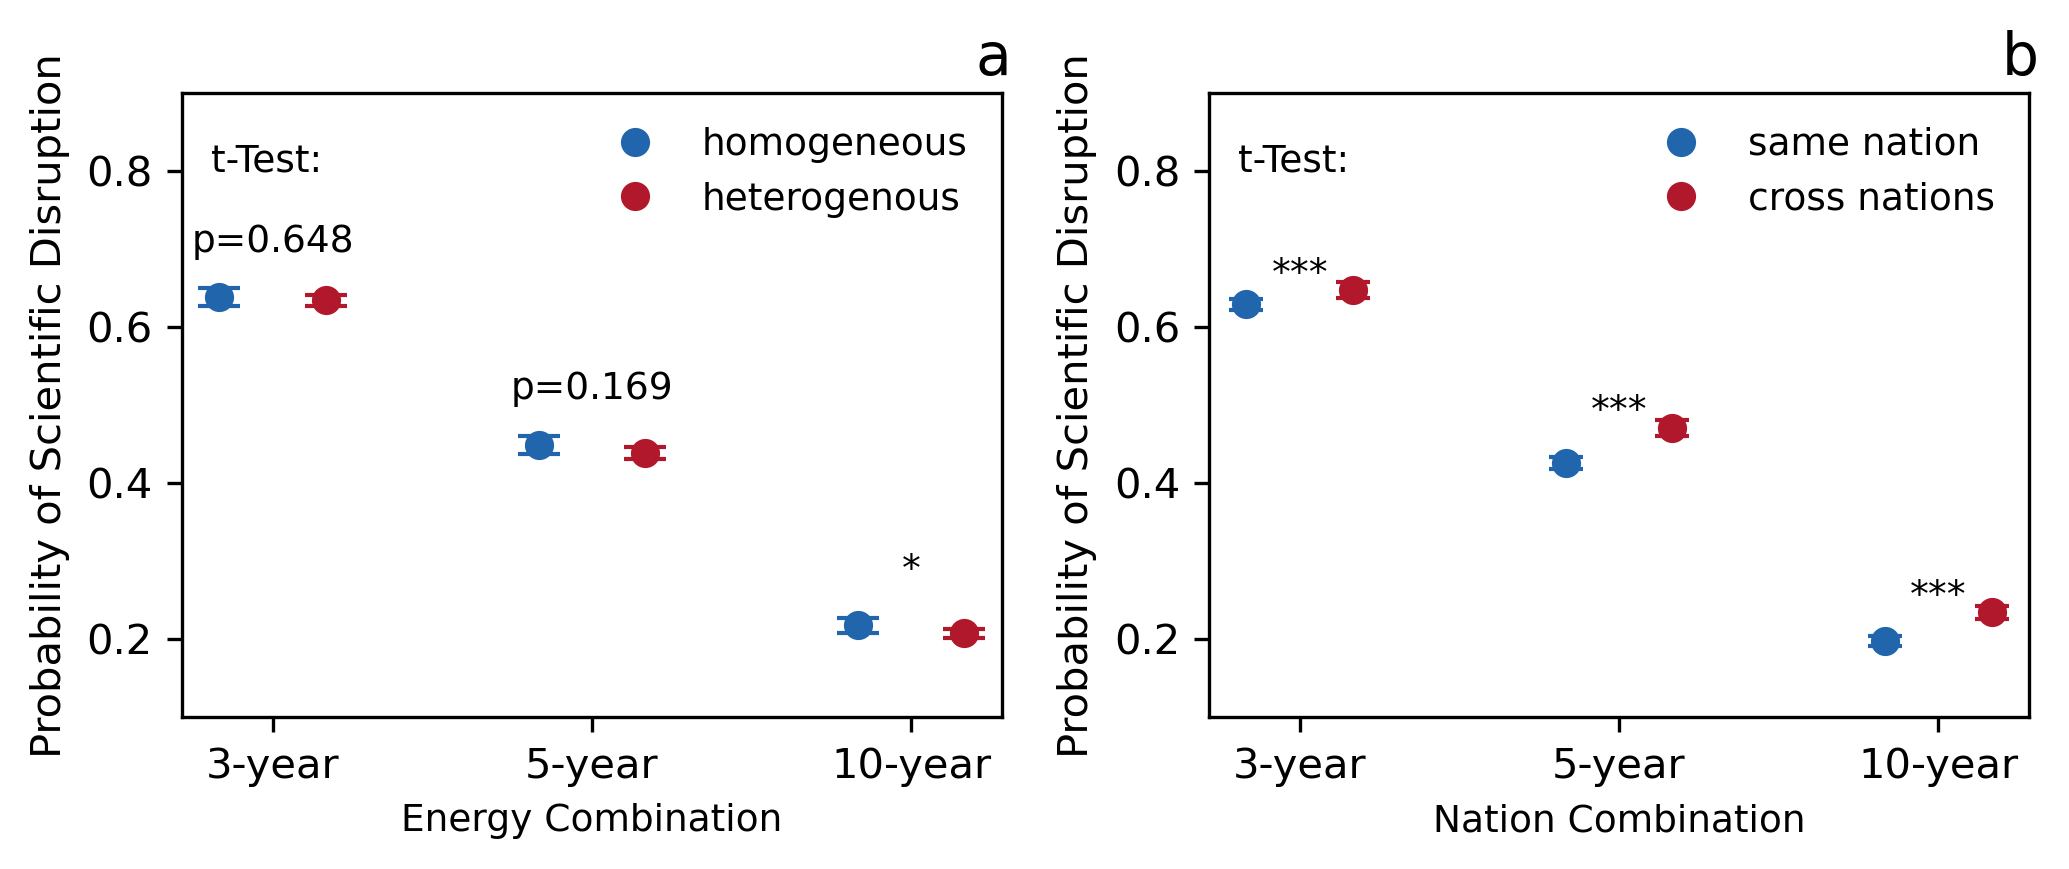

In [25]:
fig, axes = plt.subplots(1,2, figsize = (7,3),dpi = 300)
class_color = {0:'#2166ac',1:'#b2182b'}

df00 = ddf[['work_id','energy1-0','di3','num_reference','times_cited_3','published_year']]
df01 = ddf[['work_id','energy1-0','di5','num_reference','times_cited_5','published_year']]
df02 = ddf[['work_id','energy1-0','di10','num_reference','times_cited_10','published_year']]

# 数据和标签
data_list = [
    (df00, 'di3', '3-Year Disription', 1, 2),
    (df01, 'di5', '5-Year Disription', 4, 5),
    (df02, 'di10', '10-Year Disription', 7, 8)
]
df00 = df00[(df00['times_cited_3']>=5)&(df00['num_reference']>=5)&(df00['published_year']<2021)]
df01 = df01[(df01['times_cited_5']>=5)&(df01['num_reference']>=5)&(df01['published_year']<2019)]
df02 = df02[(df02['times_cited_10']>=5)&(df02['num_reference']>=5)&(df02['published_year']<2014)]
for df, col, label, x0, x1 in data_list:
    proportions = {}  # 临时记录每组的 p 和 se 用于标注
    for group, xpos in zip([0, 1], [x0, x1]):
        data = df[df['energy1-0'] == group][col].dropna()
        n = len(data)
        n_pos = (data > 0).sum()
        p = n_pos / n if n > 0 else 0
        se = np.sqrt(p * (1 - p) / n) if n > 0 else 0
        ci = 1.96 * np.sqrt(p * (1 - p) / n)
        proportions[group] = (p, se)
        # 画点 + 误差棒
        axes[0].errorbar(x=xpos, y=p, yerr=ci, fmt='o',
                         color=class_color[group], capsize=5)
    data0_bin = (df[df['energy1-0'] == 0][col] > 0).astype(int)
    data1_bin = (df[df['energy1-0'] == 1][col] > 0).astype(int)
    t_stat, p_value = ttest_ind(data0_bin, data1_bin, equal_var=False)
    print(f'{label} ({col}) t-test: t={t_stat:.3f}, p={p_value:.3f}')
    if p_value < 0.01:
        sig = '***'
    elif p_value < 0.05:
        sig = '**'
    elif p_value < 0.1:
        sig = '*'
    else:
        sig = f'p={p_value:.3f}'

    # 计算显著性标注位置（基于比例 + 标准误）
    p0, se0 = proportions[0]
    p1, se1 = proportions[1]
    y_max = max(p0, p1) + 1.5 * max(se0, se1)

    x_mid = (x0 + x1) / 2
    axes[0].text(x_mid, y_max+0.05, f'{sig}', ha='center', fontsize=9)
# 美化
axes[0].text(1.5, 0.8, 't-Test: ', ha='center', fontsize=9)
axes[0].set_xticks([1.5, 4.5, 7.5])
axes[0].set_ylim(0.1,0.9)
axes[0].yaxis.set_major_locator(MultipleLocator(0.2))
axes[0].set_xticklabels(['3-year', '5-year', '10-year'])
axes[0].set_ylabel('Probability of Scientific Disruption', fontproperties = EF)
legend_handles = [
    mlines.Line2D([], [], color=class_color[0], marker='o', linestyle='None', label='homogeneous'),
    mlines.Line2D([], [], color=class_color[1], marker='o', linestyle='None', label='heterogenous'),
]
axes[0].legend(handles=legend_handles, frameon = False, loc='upper right', fontsize = 9)
axes[0].set_xlabel('Energy Combination', fontsize = 9)

df10 = ddf[['work_id','region_d1n0','di3','num_reference','times_cited_3','published_year']]
df11 = ddf[['work_id','region_d1n0','di5','num_reference','times_cited_5','published_year']]
df12 = ddf[['work_id','region_d1n0','di10','num_reference','times_cited_10','published_year']]

# 数据和标签
data_list = [
    (df10, 'di3', '3-Year Disription', 1, 2),
    (df11, 'di5', '5-Year Disription', 4, 5),
    (df12, 'di10', '10-Year Disription', 7, 8)
]
df10 = df10[(df10['times_cited_3']>=5)&(df10['num_reference']>=5)&(df10['published_year']<2021)]
df11 = df11[(df11['times_cited_5']>=5)&(df11['num_reference']>=5)&(df11['published_year']<2019)]
df12 = df12[(df12['times_cited_10']>=5)&(df12['num_reference']>=5)&(df12['published_year']<2014)]
for df, col, label, x0, x1 in data_list:
    proportions = {}  # 临时记录每组的 p 和 se 用于标注

    for group, xpos in zip([0, 1], [x0, x1]):
        data = df[df['region_d1n0'] == group][col].dropna()
        n = len(data)
        n_pos = (data > 0).sum()
        p = n_pos / n if n > 0 else 0
        se = np.sqrt(p * (1 - p) / n) if n > 0 else 0
        ci = 1.96 * np.sqrt(p * (1 - p) / n)
        proportions[group] = (p, se)

        # 画点 + 误差棒
        axes[1].errorbar(x=xpos, y=p, yerr=ci, fmt='o',
                         color=class_color[group], capsize=4)

    data0_bin = (df[df['region_d1n0'] == 0][col] > 0).astype(int)
    data1_bin = (df[df['region_d1n0'] == 1][col] > 0).astype(int)
    t_stat, p_value = ttest_ind(data0_bin, data1_bin, equal_var=False)
    print(f'{label} ({col}) t-test: t={t_stat:.3f}, p={p_value:.3f}')
    if p_value < 0.01:
        sig = '***'
    elif p_value < 0.05:
        sig = '**'
    elif p_value < 0.1:
        sig = '*'
    else:
        sig = f'p={p_value:.3f}'

    # 计算显著性标注位置（基于比例 + 标准误）
    p0, se0 = proportions[0]
    p1, se1 = proportions[1]
    y_max = max(p0, p1) + 1.5 * max(se0, se1)

    x_mid = (x0 + x1) / 2
    axes[1].text(x_mid, y_max, f'{sig}', ha='center', fontsize=9)
# 美化
axes[1].text(1.5, 0.8, 't-Test: ', ha='center', fontsize=9)
axes[1].set_xticks([1.5, 4.5, 7.5])
axes[1].set_ylim(0.1,0.9)
axes[1].yaxis.set_major_locator(MultipleLocator(0.2))
axes[1].set_xticklabels(['3-year', '5-year', '10-year'])
axes[1].set_ylabel('Probability of Scientific Disruption', fontproperties = EF)
legend_handles = [
    mlines.Line2D([], [], color=class_color[0], marker='o', linestyle='None', label='same nation'),
    mlines.Line2D([], [], color=class_color[1], marker='o', linestyle='None', label='cross nations'),
]
axes[1].legend(handles=legend_handles, frameon = False, loc='upper right', fontsize = 9)
axes[1].set_xlabel('Nation Combination', fontsize = 9)


# axes = [axes[0],axes[1]]
for i, ax in enumerate(axes):
    ax.text(0.99, 1.01, chr(97 + i), transform=ax.transAxes, 
            fontsize=14, verticalalignment='bottom', horizontalalignment='center')
plt.tight_layout()
plt.savefig(main_path + r'Co-utilization/1-Revision202501-DataProcess/energy-region_0911.svg')
plt.show()